# Simulate neural dynamics using a wave model

In this tutorial we will use the geometric eigenmodes and eigenvalues to simulate cortical activity,
 using the [Pang *et al.* (2023)](https://doi.org/10.1038/s41586-023-06098-1) model based on neural
 field theory. Here, the spatiotemporal evolution of activity $\phi(\vec r,t)$ is described by an
 isotropic damped wave equation without regeneration,

$$
\displaystyle \bigg[\frac{1}{\gamma_s^2}\frac{\partial^2}{\partial t^2}
+\frac{2}{\gamma_s}\frac{\partial}{\partial t}+1-r_s^2\nabla^2 \bigg]\phi(\vec r,t)=Q(\vec r,t),
$$

where:
- $\gamma_s$ denotes the temporal damping parameter
- $r_s$ denotes the spatial length scale parameter
- $\nabla^2$ denotes the Laplace-Beltrami operator
- $Q(\vec r,t)$ denotes external input

As in the previous tutorials, we begin by initialising the EigenSolver with a cortical surface and
 medial wall mask, then solve for the first 200 eigenmodes. This time we can try out the macaque data.

In [ ]:
from importlib.resources import as_file, files

from nsbutils.plotting import plot_surf

from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf


In [2]:
mesh, medmask = fetch_example_surf(species='macaque')
solver = EigenSolver(mesh, mask=medmask).solve(200)

We can then call the `sim_nft_waves` class method to compute 1000 timepoints of neural activity:

In [ ]:
sim_neural = solver.sim_nft_waves(nt=1000, seed=0)

Note that Gaussian white noise is used as external input by default, with a timestep of `dt=1e-4`
seconds.

To visualise activity, we can first sample a few timepoints from the output and add the medial wall
 back in by using `unmask_data`:

In [ ]:
sim_neural_sample = solver.unmask_data(sim_neural[:, ::240])  # Sample every 240 time points

Each of these sampled timepoints can be visualised with `plot_surf` from `nsbutils`:

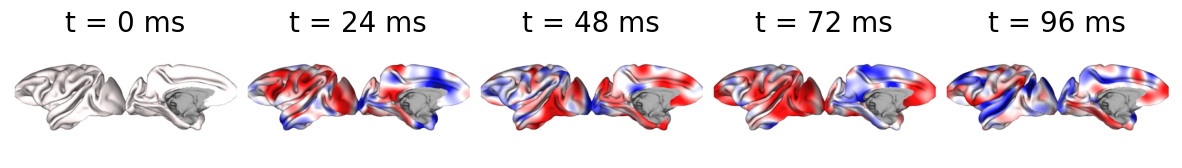

In [ ]:
lh_surfpath = files('neuromodes.data') / 'sp-macaque_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
with as_file(lh_surfpath) as lh_surfpath: 
    plot_surf(
        lh_surfpath,
        sim_neural_sample,
        labels=[f't = {i*24} ms' for i in range(5)],
        cmap='seismic_r',
        color_range='group'
    )

We can also simulate and visualise the blood oxygen level-dependent (BOLD) signal of this activity
via the Balloon-Windkessel model. Since the haemodynamic response function has a much longer
temporal scale than the wave model, we need to first simulate activity at a larger timestep:

In [15]:
dt = 0.003
nt = 4000
sim_neural = solver.sim_nft_waves(nt=nt, dt=dt, seed=0)

# Convert activity to BOLD signal
sim_bold = solver.balloon_model(sim_neural, dt=dt)

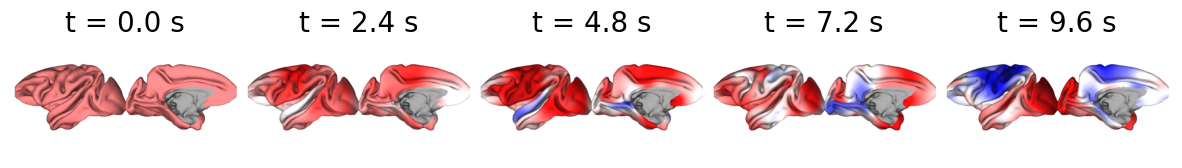

In [16]:
# Sample at 5 timepoints
n_samples = 5
sim_bold_sample = solver.unmask_data(sim_bold[:, [i * nt // n_samples for i in range(n_samples)]])

with as_file(lh_surfpath) as lh_surfpath:
    plot_surf(
        lh_surfpath,
        sim_bold_sample,
        labels=[f't = {i*dt*nt/n_samples:.1f} s' for i in range(n_samples)],
        cmap='seismic_r',
        color_range='group'
    )